In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df = pd.read_csv("anime.csv")

In [3]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [5]:
df.isnull().sum()

,0
anime_id,0
name,0
genre,62
type,25
episodes,0
rating,230
members,0


In [6]:
df.shape

(12294, 7)

In [7]:
df.columns

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')

In [8]:
df = df.dropna()
df.shape

(12017, 7)

In [9]:
df["features"] = df["genre"]

In [10]:
cv = CountVectorizer(stop_words="english")

feature_matrix = cv.fit_transform(df["features"])

In [12]:
cosine_sim = cosine_similarity(feature_matrix)

print(cosine_sim.shape)

(12017, 12017)


In [13]:
indices = pd.Series(df.index, index=df["name"]).drop_duplicates()

In [14]:
def recommend(anime_name):
    idx = indices[anime_name]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(similarity_scores,
                               key=lambda x: x[1],
                               reverse=True)

    similarity_scores = similarity_scores[1:6]

    anime_indices = [i[0] for i in similarity_scores]

    return df["name"].iloc[anime_indices]

In [15]:
recommend("Death Note")

,name
778,Death Note Rewrite
981,Mousou Dairinin
144,Higurashi no Naku Koro ni Kai
334,Higurashi no Naku Koro ni
1383,Higurashi no Naku Koro ni Rei


In [16]:
recommend("Naruto")

,name
615,Naruto: Shippuuden
841,Naruto
1103,Boruto: Naruto the Movie - Naruto ga Hokage ni...
1343,Naruto x UT
1472,Naruto: Shippuuden Movie 4 - The Lost Tower


In [17]:
print("Final Conclusion")
print("1. Loaded and explored the Anime dataset.")
print("2. Handled missing values.")
print("3. Used the genre feature to calculate similarity.")
print("4. Converted text into numerical vectors using CountVectorizer.")
print("5. Calculated cosine similarity between anime.")
print("6. Built an anime recommendation system.")
print("7. The system successfully recommends similar anime based on genre.")

Final Conclusion
1. Loaded and explored the Anime dataset.
2. Handled missing values.
3. Used the genre feature to calculate similarity.
4. Converted text into numerical vectors using CountVectorizer.
5. Calculated cosine similarity between anime.
6. Built an anime recommendation system.
7. The system successfully recommends similar anime based on genre.


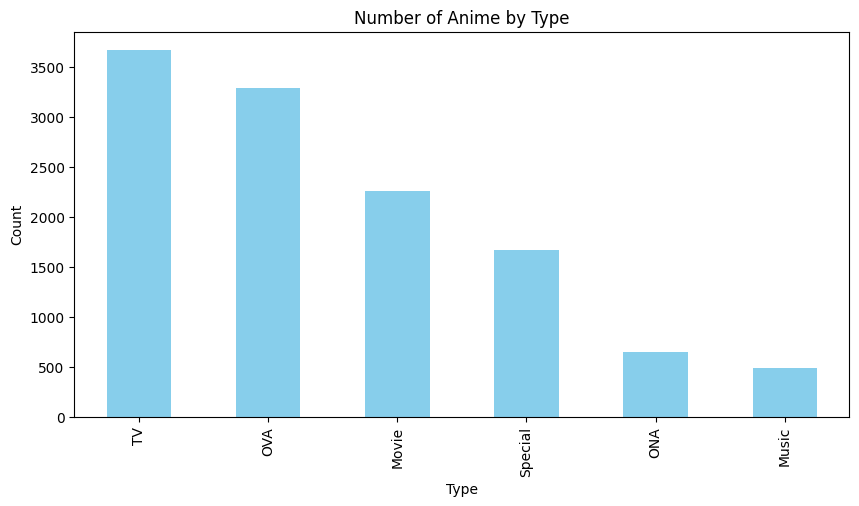

In [18]:
plt.figure(figsize=(10,5))
df["type"].value_counts().plot(kind="bar", color="skyblue")
plt.title("Number of Anime by Type")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()